In [10]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

In [11]:
#importo i dati 

data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, target_col='class', test_size=0.2, val_ratio=0.25,
    random_state=42, apply_outlier_removal=True
)
class_names = list(label_encoder.classes_)

Outliers removed: 8,715 rows  (91,285 remain)


In [12]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
  [Train] Acc=97.08%  F1=0.9709
  [Val] Acc=90.24%  F1=0.8759
Extra Trees best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  [Train] Acc=99.98%  F1=0.9998
  [Val] Acc=90.32%  F1=0.8753


In [13]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 90.51%
  Precision: 0.8750
  Recall   : 0.8835
  F1       : 0.8786
  Confusion Matrix:
[[10140   371   270]
 [  203  3101   244]
 [  260   385  3283]]

Extra Trees:
  Accuracy  : 90.40%
  Precision: 0.8770
  Recall   : 0.8767
  F1       : 0.8760
  Confusion Matrix:
[[10232   331   218]
 [  234  3089   225]
 [  329   416  3183]]


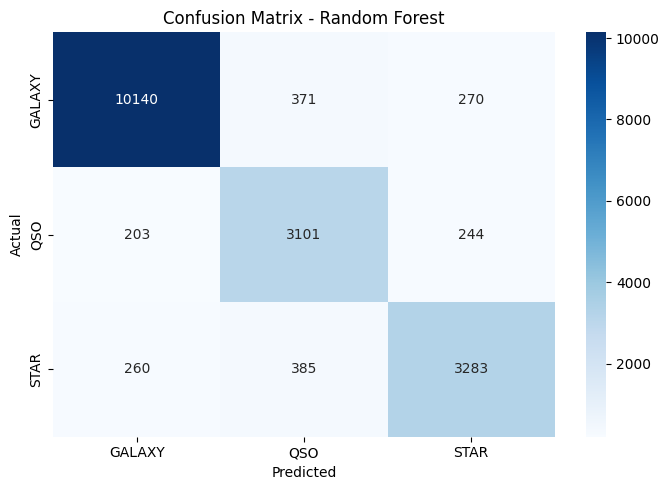

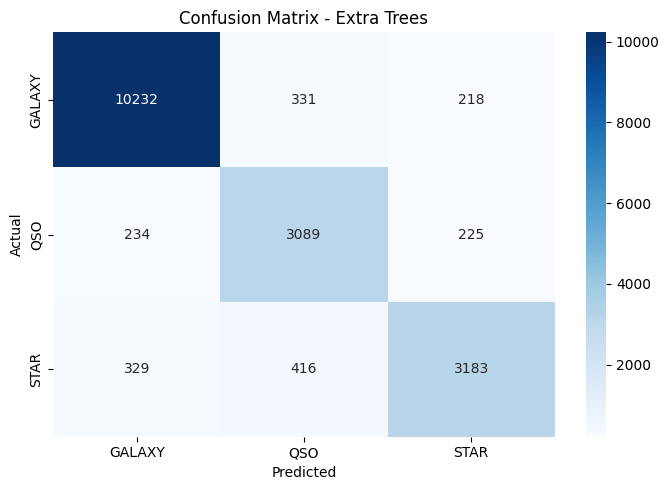

In [14]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

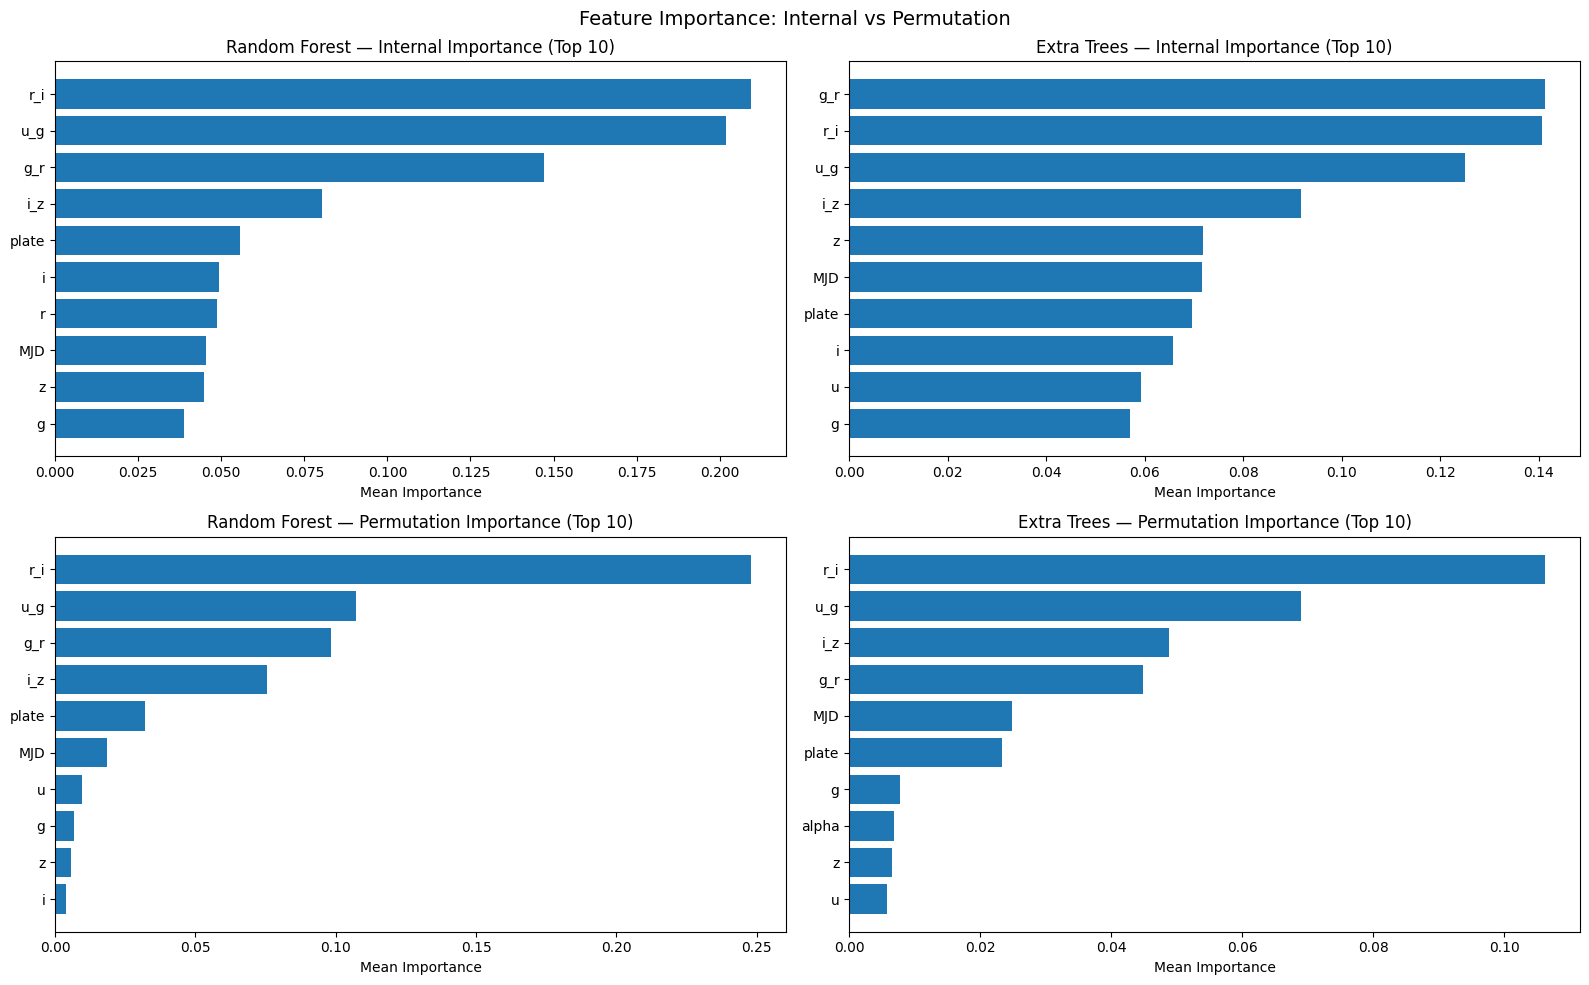

In [11]:
# Feature Importance: confronto tra metodo interno (sul train)  e permutation (sul test) 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Importance: Internal vs Permutation', fontsize=14)

results = {}

for col, (name, model) in enumerate([('Random Forest', rf_model), 
                                      ('Extra Trees', et_model)]):
    # interno (training-based)
    imp_internal = pd.Series(model.feature_importances_, 
                             index=feature_names).sort_values(ascending=False)
    sc.plot_permutation_importance(imp_internal, top_n=10, title=f'{name} — Internal Importance',
                                   ax=axes[0, col] )
    

    # permutation (test-based)
    imp_perm = sc.compute_permutation_importance(model, X_test, y_test, 
                                                  feature_names=feature_names)
    sc.plot_permutation_importance(imp_perm, top_n=10,
                                                    title=f'{name} — Permutation Importance',
                                   ax=axes[1, col])
    results[name] = {'internal': imp_internal, 'permutation': imp_perm}
   
plt.tight_layout()
plt.show()

In [13]:
# valori numerici delle feature importances
for name, res in results.items():
    print(f'\n── {name} ──')
    print('Internal:')
    print(res['internal'].to_string())
    print('\nPermutation:')
    for feat, val in res['permutation'].items():
        print(f'{feat}: {val:.4f}')


── Random Forest ──
Internal:
r_i      0.209422
u_g      0.201781
g_r      0.147089
i_z      0.080264
plate    0.055762
i        0.049191
r        0.048745
MJD      0.045437
z        0.044781
g        0.038761
u        0.031286
alpha    0.023894
delta    0.023588

Permutation:
r_i: 0.2479
u_g: 0.1071
g_r: 0.0982
i_z: 0.0756
plate: 0.0319
MJD: 0.0184
u: 0.0095
g: 0.0066
z: 0.0058
i: 0.0039
delta: 0.0034
alpha: 0.0020
r: 0.0011

── Extra Trees ──
Internal:
g_r      0.141298
r_i      0.140550
u_g      0.125009
i_z      0.091750
z        0.071756
MJD      0.071677
plate    0.069528
i        0.065692
u        0.059248
g        0.057030
r        0.047415
alpha    0.032613
delta    0.026433

Permutation:
r_i: 0.1062
u_g: 0.0689
i_z: 0.0488
g_r: 0.0449
MJD: 0.0248
plate: 0.0232
g: 0.0077
alpha: 0.0069
z: 0.0065
u: 0.0057
i: 0.0042
delta: 0.0033
r: 0.0014


## I due metodi per calcolare la feature importance

### Importanza interna (Gini-based)
L'importanza interna è calcolata **durante il training**. Ad ogni split 
di ogni albero, il modello misura di quanto quella divisione riduce 
l'impurità del nodo (criterio di Gini). L'importanza di una feature 
è la somma di tutte queste riduzioni, mediata su tutti gli alberi 
della foresta. 

È un metodo veloce, i valori sono già disponibili dopo il training 
senza nessun calcolo aggiuntivo, ma ha un limite importante: misura 
quanto una feature viene **usata**, non quanto è **utile** davvero 
sul test set. Feature ridondanti o parzialmente correlate ad altre 
possono risultare importanti anche se rimuoverle non cambierebbe nulla.

### Permutation Importance
La permutation importance viene calcolata **dopo il training, sul test set**. 
Il procedimento è:
1. Calcola l'accuracy baseline del modello sul test set
2. Prendi una feature e mescola casualmente i suoi valori, 
   così rompi qualsiasi relazione con il target mantenendo 
   invariata la distribuzione dei dati
3. Ricalcola l'accuracy sul test set modificato
4. La differenza rispetto alla baseline è l'importanza di quella feature
5. Ripeti per ogni feature

Misura quanto **peggiora la generalizzazione** se quella feature 
non è disponibile, è quindi un indicatore più affidabile 
dell'importanza reale.

## Mini analisi 

### Cosa concordano i due metodi
I due metodi concordano sulle 4 feature dominanti (`r_i`, `u_g`, `g_r`, `i_z`), 
le quali compaiono in cima a tutti e 4 i grafici.

### ET e RF divergono (internal importance) 
RF concentra il peso principalmente su `r_i` (~0.21), mentre ET ha come 
feature più importante `g_r` (~0.14), distribuendo il peso in modo più 
uniforme tra le prime quattro feature. Questo è coerente con la natura 
dei due algoritmi: RF cerca lo split ottimale ad ogni nodo, tendendo a 
favorire sempre le stesse feature; ET usa split casuali, distribuendo 
naturalmente il contributo tra più feature.

### ET e RF divergono (permutation importance) 
RF concentra nuovamente il peso su `r_i` (~0.25), confermando che è la 
feature più discriminante sul test set. Per ET invece emerge `u_g` come 
dominante, seguita da `r_i` e `i_z` con valori simili, suggerendo che 
ET sfrutta un insieme di feature leggermente diverso per generalizzare.

### Perché questa differenza tra i due metodi per ET?
Nell'importance interna ET assegna il peso massimo a `g_r`, mentre nella 
permutation importance emerge `u_g`. Questo indica che `g_r` viene usata 
frequentemente durante il training (molti split), ma quando la si mescola 
sul test set l'accuracy non cala drasticamente quanto per `u_g`. 
In altre parole, `u_g` è più *indispensabile* per la classificazione finale, 
mentre `g_r` è più *utilizzata* ma parzialmente ridondante con altre feature.

### plate e MJD 
Entrambi i modelli assegnano importanza non trascurabile a `plate` e `MJD`, 
che sono identificatori osservativi del survey SDSS, non grandezze fisiche 
intrinseche degli oggetti. La loro importanza suggerisce che i modelli 
hanno imparato correlazioni legate alla strategia di osservazione, 
non alle proprietà fisiche degli oggetti celesti. Questo è un limite 
del classificatore: funzionerebbe peggio su dati provenienti da un 
survey diverso da SDSS.

## Perché RF e ET danno risultati così diversi

### La differenza strutturale chiave

Entrambi costruiscono molti alberi e combinano le predizioni per voto 
di maggioranza. La differenza sta in **come costruiscono ogni singolo albero**.

RF ad ogni nodo:
- campiona un sottoinsieme casuale di feature
- per ognuna cerca lo split ottimale (massima riduzione di Gini)
- sceglie il migliore

ET ad ogni nodo:
- campiona un sottoinsieme casuale di feature  
- per ognuna sceglie uno split **completamente casuale**
- sceglie il migliore tra questi split casuali

### Conseguenza sull'importanza interna

RF trovando sempre lo split ottimale tende a sfruttare sempre 
le stesse feature. Questo crea una 
**dipendenza concentrata**: `r_i` (0.209) e `u_g` (0.201) dominano 
mentre le altre vengono usate molto meno.

ET con split casuali non può monopolizzare una feature, anche 
`r_i` che è la più discriminante viene usata tanto quanto `g_r` 
e `u_g` (0.140, 0.141, 0.125). Il peso è distribuito perché 
la casualità forza il modello a sfruttare tutte le feature.

### Conseguenza sull'overfitting

RF cercando sempre lo split ottimale si adatta molto ai dati di 
training, imparando pattern specifici che non generalizzano. 
ET con split casuali costruisce alberi più semplici e diversi 
tra loro, la varianza è più bassa e il modello generalizza meglio.

### Eppure le performance sul test sono quasi identiche

Questo è il risultato più interessante: nonostante il gap di 
overfitting molto diverso, RF e ET ottengono accuracy di validazione 
quasi identiche (~90%). RF non guadagna nulla dalla sua maggiore 
precisione in training, la complessità aggiuntiva non si traduce 
in migliore generalizzazione.

In questo senso ET è il modello preferibile: ottiene le stesse 
performance con meno overfitting, è più veloce da trainare 
(split casuali sono computazionalmente più leggeri di split ottimali) 
e risulta più robusto, come confermato dalla permutation importance 
dove ET distribuisce la dipendenza su più feature invece di aggrapparsi 
a `r_i` come fa RF.

In [18]:
import importlib, sys
to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]
import stellar_classification as sc

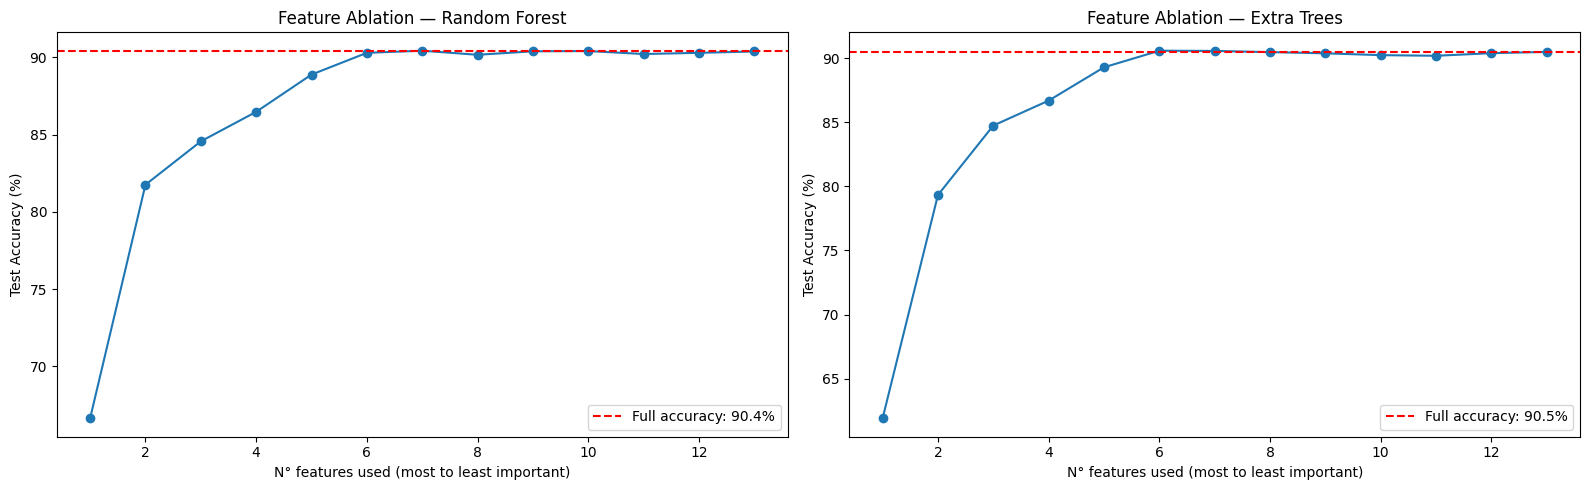

In [19]:
# Feature Ablation ( funzione che ho messo in visualization ) 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_feature_ablation(rf_model, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — Random Forest',
                         ax=axes[0])

sc.plot_feature_ablation(et_model, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — Extra Trees',
                         ax=axes[1])

plt.tight_layout()
plt.show()